# Computational Chemistry Molecular Analytics Demonstration

## GROMACS, molecular dynamics, docking, virtual screening, quantum mechanics, FEP, QSAR, Spotfire-style analytics, and OpenEye-style molecular similarity

This notebook is a **self-contained portfolio/interview notebook**. It demonstrates the logic of modern computational chemistry at the molecular analytical level using simulated data. It does **not** require licensed commercial suites such as Schrödinger, OpenEye, or Spotfire, and it does **not** require a production GROMACS installation. Instead, it simulates outputs that resemble common results from these workflows and then analyses them in a way a drug discovery team would understand.

The simulated numerical ranges are benchmarked against commonly reported ranges in PubMed-indexed computational drug discovery literature:

- **GROMACS / molecular dynamics**, RMSD, RMSF, hydrogen bonds, ligand retention, molecular simulation logic.
- **Docking and virtual screening**, docking scores, rank ordering, ligand triage.
- **Quantum mechanics-style descriptors**, HOMO, LUMO, HOMO-LUMO gap, dipole moment.
- **FEP-style lead optimisation**, relative binding free-energy changes between close analogues.
- **QSAR**, descriptor/fingerprint-based activity prediction.
- **Spotfire-style SAR analytics**, dashboard-like tables and heatmaps.
- **OpenEye-style analytics**, molecular shape and electrostatic similarity.

### Key PubMed-indexed references used as scientific anchors

1. Hess B, Kutzner C, van der Spoel D, Lindahl E. GROMACS 4: algorithms for highly efficient, load-balanced, and scalable molecular simulation. *Journal of Chemical Theory and Computation*. 2008. PMID: 26620784.
2. Trott O, Olson AJ. AutoDock Vina: improving speed and accuracy of docking and virtual screening. *Journal of Computational Chemistry*. 2010. PMID: 19499576.
3. Kitchen DB, Decornez H, Furr JR, Bajorath J. Docking and scoring in virtual screening for drug discovery. *Nature Reviews Drug Discovery*. 2004. PMID: 15520816.
4. Wang L, Wu Y, Deng Y, et al. Protein-ligand binding free energy calculations with FEP. *Chemical Reviews*. 2019. PMID: 31396905.
5. Arodola OA, Soliman MES. Quantum mechanics implementation in drug-design workflows. *Drug Design, Development and Therapy*. 2017.
6. Carracedo-Reboredo P, Liñares-Blanco J, Rodríguez-Fernández N, et al. Machine learning approaches and trends in drug discovery. *Computational and Structural Biotechnology Journal*. 2021.
7. Nicholls A, McGaughey GB, Sheridan RP, et al. Molecular shape and medicinal chemistry: a perspective. *Journal of Medicinal Chemistry*. 2010.
8. Agrafiotis DK, Shemanarev M, Connolly PJ, Farnum M, Lobanov VS. SAR maps: a new SAR visualization technique for medicinal chemists. *Journal of Medicinal Chemistry*. 2007. PMID: 17958407.

> Note: “Sportfire” may refer to **Spotfire**, a data visualisation/SAR analytics platform used in pharma, or to a specific QSAR platform. This notebook demonstrates a Spotfire-style SAR decision dashboard.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

try:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
    from sklearn.metrics import (
        roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
        classification_report, mean_absolute_error, mean_squared_error, r2_score
    )
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print("scikit-learn unavailable. Install with: pip install scikit-learn")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("Ready. Figures will be saved in:", FIG_DIR.resolve())

Ready. Figures will be saved in: /Users/petalc01/Gromacs QSAR Openeye molecular docking/figures


## 1. Simulated molecular drug discovery dataset

In [5]:
# 1. Simulate a realistic molecular drug discovery dataset

n = 240
compound_ids = [f"CMPD_{i:04d}" for i in range(1, n + 1)]

series = np.random.choice(
    ["A_urea_core", "B_pyridine_core", "C_indole_core", "D_fragment_core"],
    size=n,
    p=[0.34, 0.28, 0.23, 0.15]
)

smiles_fragments = {
    "A_urea_core": "c1cc(NC(=O)N)ccc1",
    "B_pyridine_core": "n1ccccc1C(=O)N",
    "C_indole_core": "c1ccc2[nH]ccc2c1",
    "D_fragment_core": "CC(=O)Nc1ccccc1"
}
SMILES_like = [smiles_fragments[s] + np.random.choice(["F", "Cl", "C", "OC", "N", ""]) for s in series]

MW = np.clip(np.random.normal(365, 75, n), 180, 620)
cLogP = np.clip(np.random.normal(2.7, 1.25, n), -0.8, 6.2)
TPSA = np.clip(np.random.normal(82, 32, n), 20, 180)
HBD = np.clip(np.random.poisson(1.4, n), 0, 6)
HBA = np.clip(np.random.poisson(5.0, n), 1, 12)
rot_bonds = np.clip(np.random.poisson(5.0, n), 0, 15)
aromatic_rings = np.clip(np.random.poisson(2.0, n), 0, 5)
formal_charge = np.random.choice([-1, 0, 1], size=n, p=[0.08, 0.82, 0.10])

# OpenEye/ROCS-style similarity surrogates
shape_similarity = np.clip(np.random.beta(5, 2, n), 0.15, 0.99)
electrostatic_similarity = np.clip(np.random.beta(4, 2.5, n), 0.10, 0.98)
combo_similarity = 0.55 * shape_similarity + 0.45 * electrostatic_similarity

core_bonus = pd.Series(series).map({
    "A_urea_core": -1.0,
    "B_pyridine_core": -0.65,
    "C_indole_core": -0.35,
    "D_fragment_core": 0.20
}).values

# Docking score, kcal/mol. More negative is better.
docking_score = (
    -5.2
    - 3.2 * combo_similarity
    - 0.22 * aromatic_rings
    - 0.12 * HBA
    + 0.22 * np.maximum(cLogP - 4.5, 0)
    + 0.012 * np.maximum(TPSA - 120, 0)
    + core_bonus
    + np.random.normal(0, 0.65, n)
)
docking_score = np.clip(docking_score, -12.8, -4.2)

# FEP-style relative ΔΔG, kcal/mol. Lower is better.
FEP_ddG = (
    0.70 * (docking_score + 8.0)
    - 1.20 * (shape_similarity - 0.65)
    - 0.55 * (electrostatic_similarity - 0.60)
    + np.random.normal(0, 0.55, n)
)
FEP_ddG = np.clip(FEP_ddG, -3.2, 3.2)

# Quantum mechanics-style electronic descriptors
HOMO_eV = np.clip(np.random.normal(-6.2, 0.55, n) + 0.12 * (cLogP - 2.5), -8.2, -4.5)
LUMO_eV = np.clip(HOMO_eV + np.random.normal(4.5, 0.55, n), -2.5, 1.8)
HOMO_LUMO_gap_eV = LUMO_eV - HOMO_eV
dipole_D = np.clip(np.random.normal(3.8, 1.4, n) + 0.015 * TPSA, 0.5, 9.5)

# ADMET-style values
solubility_logS = np.clip(-0.9 - 0.58 * cLogP - 0.002 * MW + np.random.normal(0, 0.35, n), -6.5, 0.5)
permeability_logPapp = np.clip(-6.2 + 0.18 * cLogP - 0.006 * TPSA + np.random.normal(0, 0.20, n), -8.5, -4.6)
microsomal_stability_pct = np.clip(72 - 7.5 * cLogP - 0.035 * MW + np.random.normal(0, 10, n), 5, 98)

# Biological activity, pIC50
pIC50 = (
    5.1
    + 0.42 * (-docking_score - 6)
    - 0.55 * FEP_ddG
    + 1.15 * (combo_similarity - 0.55)
    - 0.10 * np.maximum(cLogP - 4.2, 0)
    - 0.006 * np.maximum(TPSA - 120, 0)
    + 0.08 * aromatic_rings
    + np.random.normal(0, 0.38, n)
)
pIC50 = np.clip(pIC50, 4.1, 9.8)
IC50_nM = 10 ** (9 - pIC50)
active = (pIC50 >= 6.5).astype(int)

# Fingerprint-like QSAR bits
fp = np.random.binomial(1, 0.20, size=(n, 64))
fp[:, 3] = (series == "A_urea_core").astype(int)
fp[:, 7] = (shape_similarity > 0.72).astype(int)
fp[:, 12] = (electrostatic_similarity > 0.68).astype(int)
fp[:, 21] = (TPSA < 110).astype(int)
fp[:, 33] = (cLogP < 4.0).astype(int)

df = pd.DataFrame({
    "compound_id": compound_ids,
    "SMILES_like": SMILES_like,
    "series": series,
    "MW": MW,
    "cLogP": cLogP,
    "TPSA": TPSA,
    "HBD": HBD,
    "HBA": HBA,
    "rot_bonds": rot_bonds,
    "aromatic_rings": aromatic_rings,
    "formal_charge": formal_charge,
    "shape_similarity_OpenEye_style": shape_similarity,
    "electrostatic_similarity_OpenEye_style": electrostatic_similarity,
    "combo_similarity": combo_similarity,
    "docking_score_kcal_mol": docking_score,
    "FEP_ddG_kcal_mol": FEP_ddG,
    "HOMO_eV": HOMO_eV,
    "LUMO_eV": LUMO_eV,
    "HOMO_LUMO_gap_eV": HOMO_LUMO_gap_eV,
    "dipole_D": dipole_D,
    "solubility_logS": solubility_logS,
    "permeability_logPapp": permeability_logPapp,
    "microsomal_stability_pct": microsomal_stability_pct,
    "pIC50": pIC50,
    "IC50_nM": IC50_nM,
    "active": active
})

for i in range(fp.shape[1]):
    df[f"FP_{i:02d}"] = fp[:, i]

df["Lipinski_violations"] = (
    (df["MW"] > 500).astype(int)
    + (df["cLogP"] > 5).astype(int)
    + (df["HBD"] > 5).astype(int)
    + (df["HBA"] > 10).astype(int)
)

df["ADMET_flag"] = np.where(
    (df["Lipinski_violations"] <= 1)
    & (df["solubility_logS"] > -5.2)
    & (df["microsomal_stability_pct"] > 25),
    "acceptable",
    "risk"
)

df["lead_score"] = (
    1.4 * df["pIC50"]
    + 0.7 * (-df["docking_score_kcal_mol"])
    + 0.9 * (-df["FEP_ddG_kcal_mol"])
    + 1.0 * df["combo_similarity"]
    + 0.02 * df["microsomal_stability_pct"]
    - 0.35 * df["Lipinski_violations"]
    + 0.25 * (df["ADMET_flag"] == "acceptable").astype(int)
)

df = df.sort_values("lead_score", ascending=False).reset_index(drop=True)
df.to_csv("simulated_molecular_analytics_dataset.csv", index=False)

print("Dataset shape:", df.shape)
display(df.head(10))

Dataset shape: (240, 93)


,compound_id,SMILES_like,series,MW,cLogP,TPSA,HBD,HBA,rot_bonds,aromatic_rings,formal_charge,shape_similarity_OpenEye_style,electrostatic_similarity_OpenEye_style,combo_similarity,docking_score_kcal_mol,FEP_ddG_kcal_mol,HOMO_eV,LUMO_eV,HOMO_LUMO_gap_eV,dipole_D,solubility_logS,permeability_logPapp,microsomal_stability_pct,pIC50,IC50_nM,active,FP_00,FP_01,FP_02,FP_03,FP_04,FP_05,FP_06,FP_07,FP_08,FP_09,FP_10,FP_11,FP_12,FP_13,FP_14,FP_15,FP_16,FP_17,FP_18,FP_19,FP_20,FP_21,FP_22,FP_23,FP_24,FP_25,FP_26,FP_27,FP_28,FP_29,FP_30,FP_31,FP_32,FP_33,FP_34,FP_35,FP_36,FP_37,FP_38,FP_39,FP_40,FP_41,FP_42,FP_43,FP_44,FP_45,FP_46,FP_47,FP_48,FP_49,FP_50,FP_51,FP_52,FP_53,FP_54,FP_55,FP_56,FP_57,FP_58,FP_59,FP_60,FP_61,FP_62,FP_63,Lipinski_violations,ADMET_flag,lead_score
0,CMPD_0161,n1ccccc1C(=O)NCl,B_pyridine_core,491.219485,2.288336,119.231535,1,6,3,4,1,0.845683,0.822933,0.835445,-11.251371,-3.101216,-6.197290,-1.094555,5.102735,6.805714,-3.255211,-6.248830,29.319587,9.800000,0.158489,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,acceptable,26.058892
1,CMPD_0174,c1cc(NC(=O)N)ccc1Cl,A_urea_core,367.672659,1.021617,82.745843,4,4,4,4,0,0.944846,0.895116,0.922467,-11.356835,-2.462176,-6.175383,-1.501375,4.674008,6.621636,-1.855176,-6.667130,38.578612,9.019448,0.956208,1,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,acceptable,24.737009
2,CMPD_0235,c1cc(NC(=O)N)ccc1N,A_urea_core,514.775612,3.529672,100.278205,0,3,7,3,-1,0.777102,0.717259,0.750173,-11.734910,-2.526812,-5.361955,-0.659520,4.702435,3.913804,-4.056335,-5.922880,45.677276,9.052415,0.886308,1,0,0,0,1,0,0,0,1,1,0,1,0,1,1,0,0,1,1,0,0,1,1,0,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,acceptable,24.725667
3,CMPD_0107,n1ccccc1C(=O)NN,B_pyridine_core,301.360948,2.837316,117.253015,2,6,3,5,1,0.769544,0.542333,0.667299,-11.398855,-2.287967,-5.791578,-1.601194,4.190384,5.921852,-3.417745,-6.489068,35.875072,9.193188,0.640933,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,acceptable,24.543632
4,CMPD_0149,c1cc(NC(=O)N)ccc1F,A_urea_core,407.016928,0.583417,78.384263,1,10,6,2,0,0.758096,0.702273,0.732976,-10.845902,-3.131052,-7.713702,-2.500000,5.213702,7.049034,-2.125724,-6.718021,42.560497,8.767952,1.706273,1,0,0,0,1,1,1,0,1,1,1,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,acceptable,24.519396
5,CMPD_0024,n1ccccc1C(=O)NF,B_pyridine_core,370.925676,3.707169,80.396186,2,7,3,2,0,0.868143,0.737144,0.809194,-10.846598,-2.525296,-5.585747,-0.708971,4.876776,6.434011,-3.660079,-5.890467,29.292558,9.180394,0.660095,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,acceptable,24.362981
6,CMPD_0202,c1cc(NC(=O)N)ccc1Cl,A_urea_core,513.960230,2.430393,60.857368,1,4,4,2,0,0.960661,0.878108,0.923512,-10.562340,-2.112448,-5.344859,-0.960728,4.384132,4.329516,-3.272921,-6.061713,45.830166,9.433191,0.368815,1,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,1,1,1,0,0,0,1,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,1,acceptable,24.241424
7,CMPD_0188,n1ccccc1C(=O)NC,B_pyridine_core,328.342263,2.858491,80.692546,0,6,10,1,0,0.953946,0.639984,0.812663,-10.261927,-2.685314,-6.108356,-2.125738,3.982618,6.841848,-3.296544,-6.199295,52.323570,8.867790,1.355845,1,1,0,0,0,0,0,1,1,0,1,1,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,acceptable,24.124171
8,CMPD_0005,c1cc(NC(=O)N)ccc1N,A_urea_core,394.403142,3.554952,86.637997,3,1,7,1,0,0.916129,0.805897,0.866525,-10.485459,-2.332945,-6.139973,-1.110481,5.029492,4.478286,-3.858933,-6.189517,36.683648,9.162167,0.688387,1,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0

## 2. Molecular series summary

In [8]:
# 2. Molecular series summary

summary = df.groupby("series").agg(
    n=("compound_id", "count"),
    active_rate=("active", "mean"),
    median_pIC50=("pIC50", "median"),
    median_docking=("docking_score_kcal_mol", "median"),
    median_FEP_ddG=("FEP_ddG_kcal_mol", "median"),
    median_combo_similarity=("combo_similarity", "median"),
    acceptable_ADMET_rate=("ADMET_flag", lambda x: np.mean(x == "acceptable"))
).reset_index()

summary["active_rate"] = (100 * summary["active_rate"]).round(1)
summary["acceptable_ADMET_rate"] = (100 * summary["acceptable_ADMET_rate"]).round(1)
display(summary.round(3))

,series,n,active_rate,median_pIC50,median_docking,median_FEP_ddG,median_combo_similarity,acceptable_ADMET_rate
0,A_urea_core,96,78.1,7.291,-9.271,-0.933,0.678,85.4
1,B_pyridine_core,54,68.5,7.237,-9.217,-0.954,0.684,85.2
2,C_indole_core,56,58.9,6.993,-8.727,-0.728,0.659,76.8
3,D_fragment_core,34,32.4,6.193,-8.104,0.074,0.653,79.4


## 3. Molecular descriptor distributions

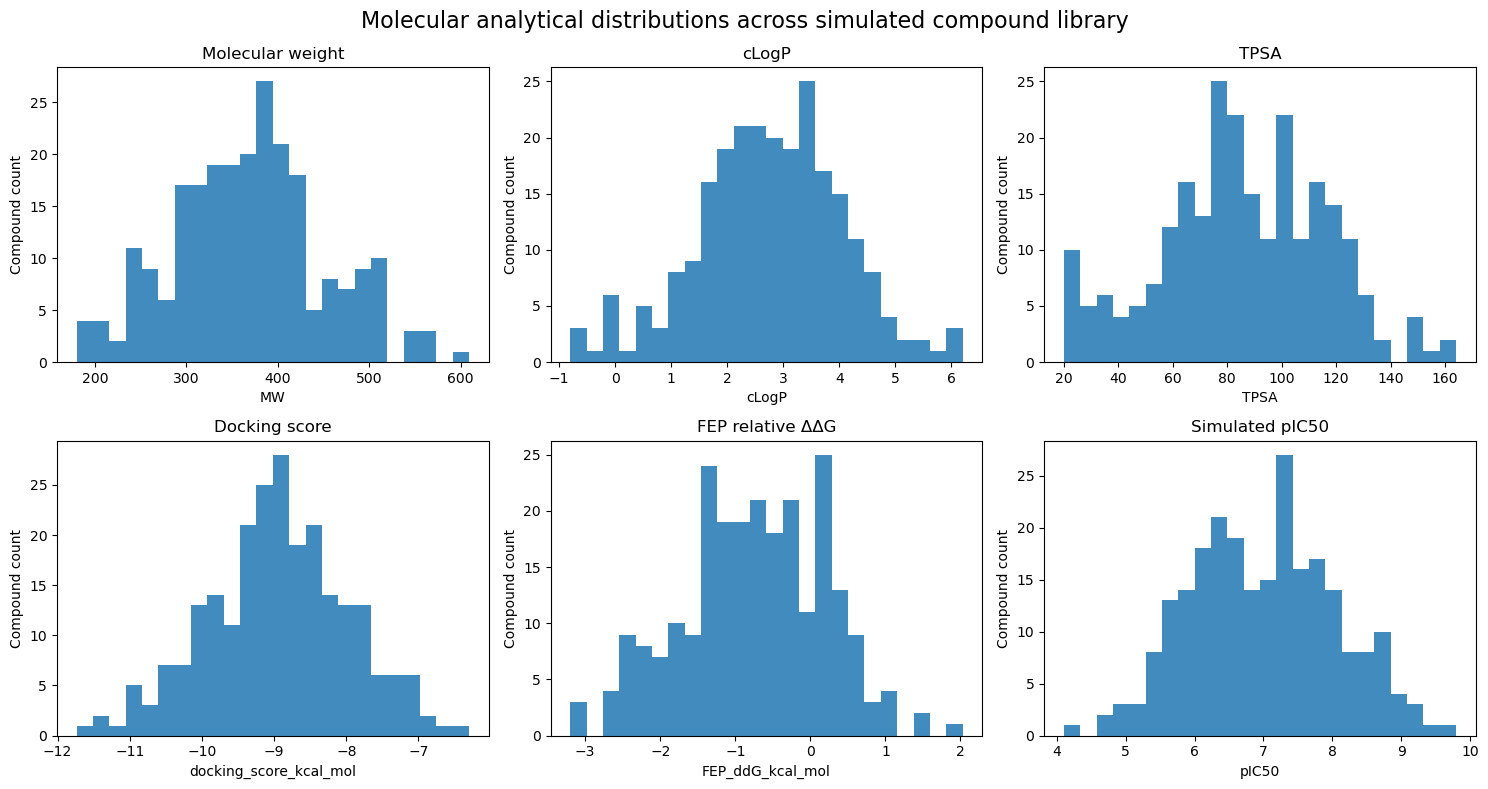

In [11]:
# 3. Molecular descriptor and activity distributions

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ["MW", "cLogP", "TPSA", "docking_score_kcal_mol", "FEP_ddG_kcal_mol", "pIC50"]
titles = ["Molecular weight", "cLogP", "TPSA", "Docking score", "FEP relative ΔΔG", "Simulated pIC50"]

for ax, col, title in zip(axes.ravel(), cols, titles):
    ax.hist(df[col], bins=24, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Compound count")

fig.suptitle("Molecular analytical distributions across simulated compound library", fontsize=16)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_molecular_distributions.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. Docking and virtual screening

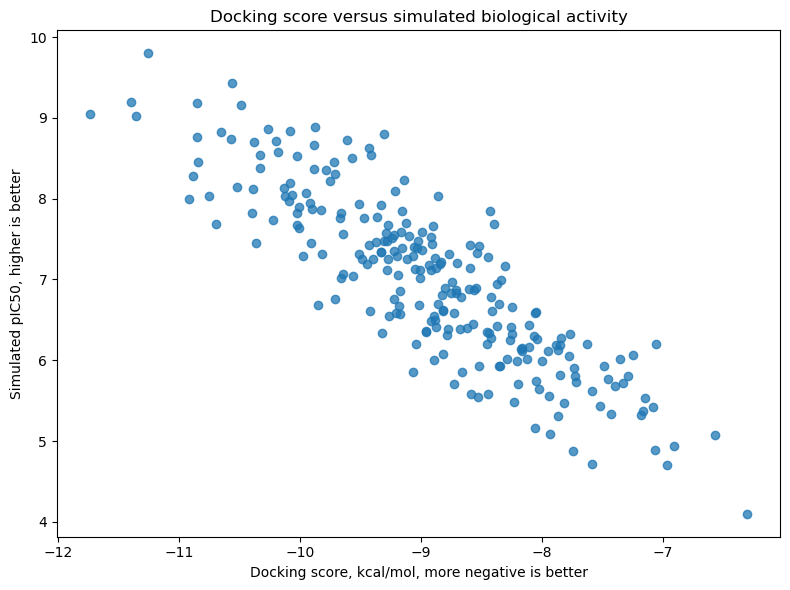

,compound_id,series,docking_score_kcal_mol,pIC50,IC50_nM,ADMET_flag,lead_score
2,CMPD_0235,A_urea_core,-11.735,9.052,0.886,acceptable,24.726
3,CMPD_0107,B_pyridine_core,-11.399,9.193,0.641,acceptable,24.544
1,CMPD_0174,A_urea_core,-11.357,9.019,0.956,acceptable,24.737
0,CMPD_0161,B_pyridine_core,-11.251,9.800,0.158,acceptable,26.059
19,CMPD_0226,A_urea_core,-10.919,7.993,10.152,acceptable,22.577
14,CMPD_0027,A_urea_core,-10.882,8.278,5.274,acceptable,23.122
5,CMPD_0024,B_pyridine_core,-10.847,9.180,0.660,acceptable,24.363
4,CMPD_0149,A_urea_core,-10.846,8.768,1.706,acceptable,24.519
33,CMPD_0169,A_urea_core,-10.842,8.452,3.529,risk,21.876
26,CMPD_0040,B_pyridine_core,-10.746,8.037,9.184,acceptable,22.159


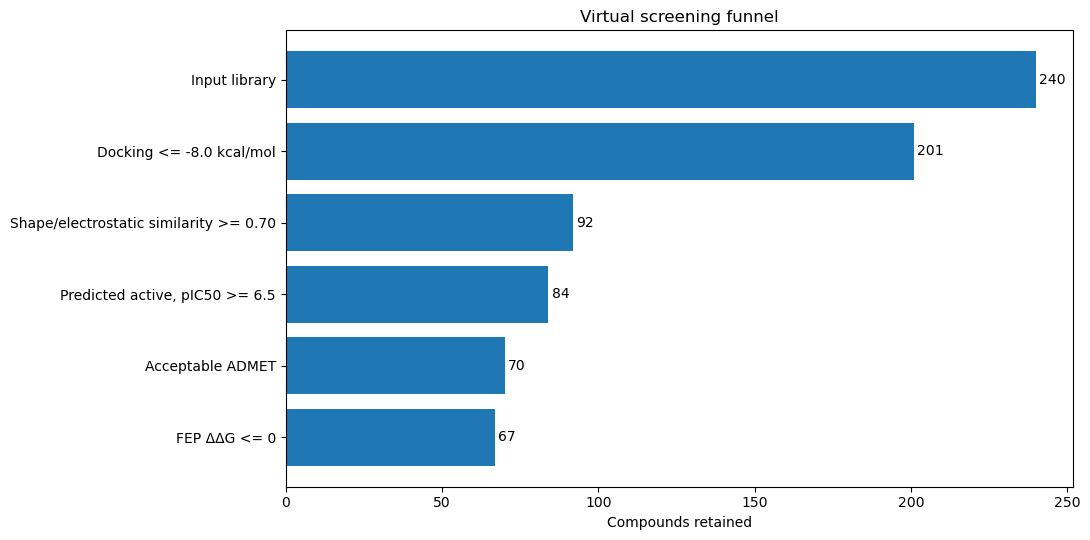

,stage,compound_count
0,Input library,240
1,Docking <= -8.0 kcal/mol,201
2,Shape/electrostatic similarity >= 0.70,92
3,"Predicted active, pIC50 >= 6.5",84
4,Acceptable ADMET,70
5,FEP ΔΔG <= 0,67


In [14]:
# 4. Docking and virtual screening analysis

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["docking_score_kcal_mol"], df["pIC50"], alpha=0.75)
ax.set_xlabel("Docking score, kcal/mol, more negative is better")
ax.set_ylabel("Simulated pIC50, higher is better")
ax.set_title("Docking score versus simulated biological activity")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_docking_vs_pIC50.png", dpi=220, bbox_inches="tight")
plt.show()

top_docking = df.sort_values("docking_score_kcal_mol").head(15)[
    ["compound_id", "series", "docking_score_kcal_mol", "pIC50", "IC50_nM", "ADMET_flag", "lead_score"]
]
display(top_docking.round(3))

# Virtual screening funnel
funnel = pd.DataFrame({
    "stage": [
        "Input library",
        "Docking <= -8.0 kcal/mol",
        "Shape/electrostatic similarity >= 0.70",
        "Predicted active, pIC50 >= 6.5",
        "Acceptable ADMET",
        "FEP ΔΔG <= 0"
    ],
    "compound_count": [
        len(df),
        (df["docking_score_kcal_mol"] <= -8.0).sum(),
        ((df["docking_score_kcal_mol"] <= -8.0) & (df["combo_similarity"] >= 0.70)).sum(),
        ((df["docking_score_kcal_mol"] <= -8.0) & (df["combo_similarity"] >= 0.70) & (df["pIC50"] >= 6.5)).sum(),
        ((df["docking_score_kcal_mol"] <= -8.0) & (df["combo_similarity"] >= 0.70) & (df["pIC50"] >= 6.5) & (df["ADMET_flag"] == "acceptable")).sum(),
        ((df["docking_score_kcal_mol"] <= -8.0) & (df["combo_similarity"] >= 0.70) & (df["pIC50"] >= 6.5) & (df["ADMET_flag"] == "acceptable") & (df["FEP_ddG_kcal_mol"] <= 0)).sum()
    ]
})

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(funnel["stage"], funnel["compound_count"])
ax.invert_yaxis()
ax.set_xlabel("Compounds retained")
ax.set_title("Virtual screening funnel")
for i, v in enumerate(funnel["compound_count"]):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_virtual_screening_funnel.png", dpi=220, bbox_inches="tight")
plt.show()

display(funnel)

## 5. GROMACS and molecular dynamics-style analytics

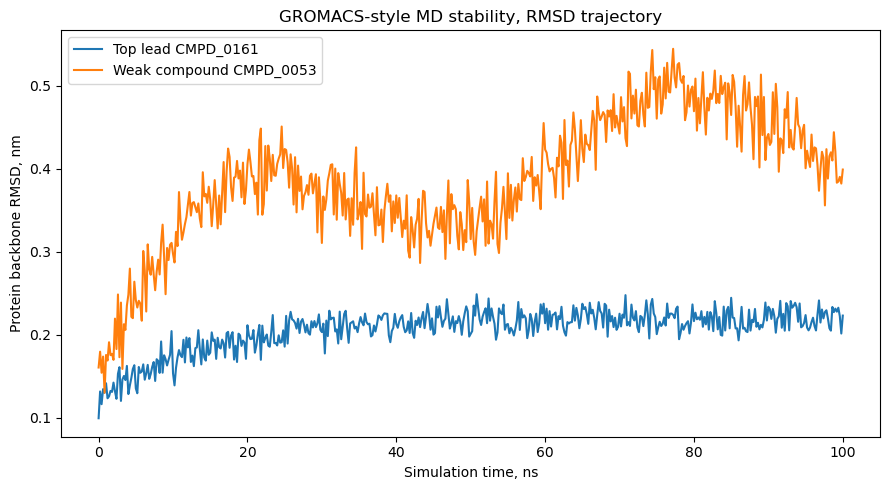

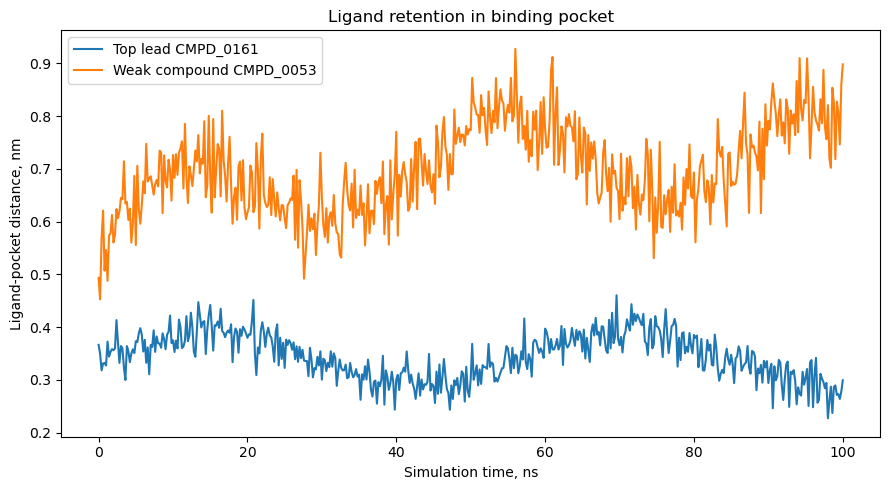

,compound,mean_RMSD_nm,mean_Rg_nm,mean_Hbonds,mean_ligand_pocket_distance_nm
0,CMPD_0161,0.206,2.122,3.222,0.345
1,CMPD_0053,0.387,2.149,1.327,0.699


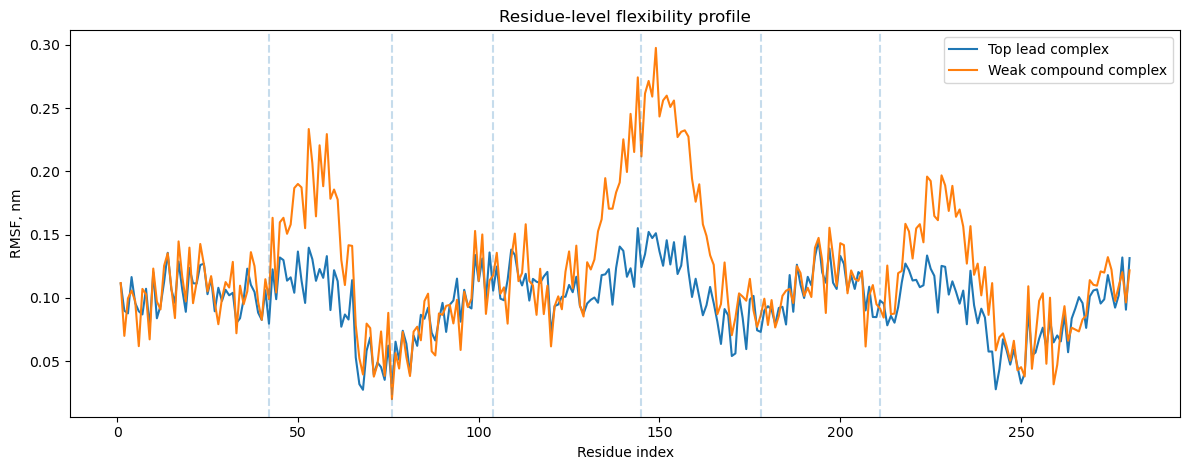

In [17]:
# 5. GROMACS / Molecular Dynamics-style trajectory analytics

time_ns = np.linspace(0, 100, 501)
top = df.iloc[0]
weak = df.sort_values("lead_score").iloc[0]

def simulate_md_trace(stability="stable"):
    if stability == "stable":
        rmsd = 0.12 + 0.10 * (1 - np.exp(-time_ns / 14)) + np.random.normal(0, 0.012, len(time_ns))
        rg = 2.12 + 0.015 * np.sin(time_ns / 13) + np.random.normal(0, 0.006, len(time_ns))
        hbonds = np.clip(np.random.normal(3.2, 0.7, len(time_ns)), 0, 6)
        distance = 0.34 + 0.05 * np.sin(time_ns / 9) + np.random.normal(0, 0.025, len(time_ns))
    else:
        rmsd = 0.15 + 0.28 * (1 - np.exp(-time_ns / 20)) + 0.07 * np.sin(time_ns / 10) + np.random.normal(0, 0.025, len(time_ns))
        rg = 2.15 + 0.035 * np.sin(time_ns / 8) + np.random.normal(0, 0.015, len(time_ns))
        hbonds = np.clip(np.random.normal(1.3, 0.8, len(time_ns)), 0, 5)
        distance = 0.55 + 0.20 * (1 - np.exp(-time_ns / 30)) + 0.08 * np.sin(time_ns / 7) + np.random.normal(0, 0.05, len(time_ns))
    return pd.DataFrame({
        "time_ns": time_ns,
        "RMSD_nm": np.clip(rmsd, 0.05, None),
        "Rg_nm": rg,
        "protein_ligand_Hbonds": hbonds,
        "ligand_pocket_distance_nm": np.clip(distance, 0.15, None)
    })

md_top = simulate_md_trace("stable")
md_weak = simulate_md_trace("unstable")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(md_top["time_ns"], md_top["RMSD_nm"], label=f"Top lead {top.compound_id}")
ax.plot(md_weak["time_ns"], md_weak["RMSD_nm"], label=f"Weak compound {weak.compound_id}")
ax.set_xlabel("Simulation time, ns")
ax.set_ylabel("Protein backbone RMSD, nm")
ax.set_title("GROMACS-style MD stability, RMSD trajectory")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_md_rmsd.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(md_top["time_ns"], md_top["ligand_pocket_distance_nm"], label=f"Top lead {top.compound_id}")
ax.plot(md_weak["time_ns"], md_weak["ligand_pocket_distance_nm"], label=f"Weak compound {weak.compound_id}")
ax.set_xlabel("Simulation time, ns")
ax.set_ylabel("Ligand-pocket distance, nm")
ax.set_title("Ligand retention in binding pocket")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_md_ligand_distance.png", dpi=220, bbox_inches="tight")
plt.show()

md_summary = pd.DataFrame({
    "compound": [top.compound_id, weak.compound_id],
    "mean_RMSD_nm": [md_top["RMSD_nm"].mean(), md_weak["RMSD_nm"].mean()],
    "mean_Rg_nm": [md_top["Rg_nm"].mean(), md_weak["Rg_nm"].mean()],
    "mean_Hbonds": [md_top["protein_ligand_Hbonds"].mean(), md_weak["protein_ligand_Hbonds"].mean()],
    "mean_ligand_pocket_distance_nm": [md_top["ligand_pocket_distance_nm"].mean(), md_weak["ligand_pocket_distance_nm"].mean()]
})
display(md_summary.round(3))

# Residue-level RMSF
residues = np.arange(1, 281)
active_site_residues = [42, 76, 104, 145, 178, 211]
rmsf_base = 0.08 + 0.035 * np.sin(residues / 14) + np.random.normal(0, 0.015, len(residues))
loop_peaks = (
    0.12 * np.exp(-((residues - 55) / 10) ** 2)
    + 0.18 * np.exp(-((residues - 150) / 14) ** 2)
    + 0.10 * np.exp(-((residues - 230) / 12) ** 2)
)
rmsf_top = np.clip(rmsf_base + loop_peaks * 0.55, 0.02, None)
rmsf_weak = np.clip(rmsf_base + loop_peaks * 1.25 + np.random.normal(0, 0.015, len(residues)), 0.02, None)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(residues, rmsf_top, label="Top lead complex")
ax.plot(residues, rmsf_weak, label="Weak compound complex")
for r in active_site_residues:
    ax.axvline(r, linestyle="--", alpha=0.25)
ax.set_xlabel("Residue index")
ax.set_ylabel("RMSF, nm")
ax.set_title("Residue-level flexibility profile")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_md_rmsf.png", dpi=220, bbox_inches="tight")
plt.show()

## 6. Quantum mechanics-style descriptors and FEP-style lead optimisation

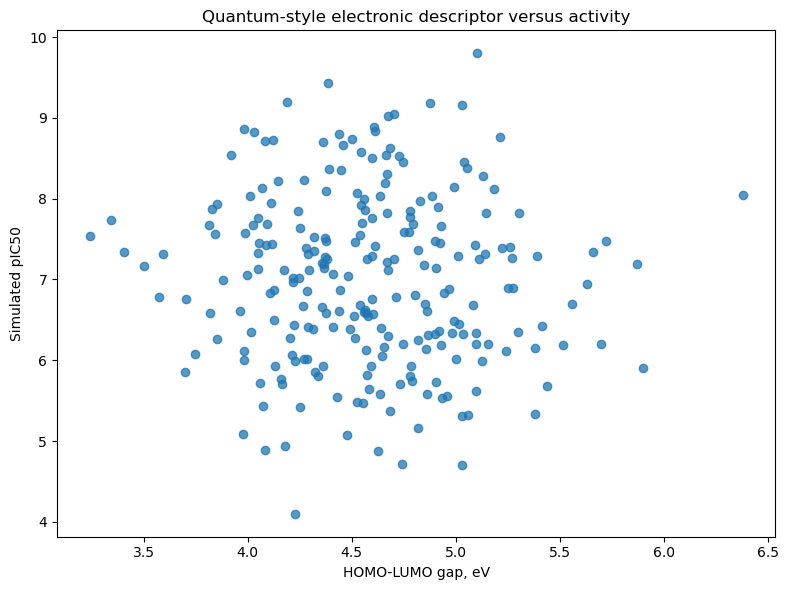

,compound_id,series,HOMO_eV,LUMO_eV,HOMO_LUMO_gap_eV,dipole_D,pIC50,docking_score_kcal_mol
0,CMPD_0161,B_pyridine_core,-6.197,-1.095,5.103,6.806,9.800,-11.251
1,CMPD_0174,A_urea_core,-6.175,-1.501,4.674,6.622,9.019,-11.357
2,CMPD_0235,A_urea_core,-5.362,-0.660,4.702,3.914,9.052,-11.735
3,CMPD_0107,B_pyridine_core,-5.792,-1.601,4.190,5.922,9.193,-11.399
4,CMPD_0149,A_urea_core,-7.714,-2.500,5.214,7.049,8.768,-10.846
5,CMPD_0024,B_pyridine_core,-5.586,-0.709,4.877,6.434,9.180,-10.847
6,CMPD_0202,A_urea_core,-5.345,-0.961,4.384,4.330,9.433,-10.562
7,CMPD_0188,B_pyridine_core,-6.108,-2.126,3.983,6.842,8.868,-10.262
8,CMPD_0005,A_urea_core,-6.140,-1.110,5.029,4.478,9.162,-10.485
9,CMPD_0118,A_urea_core,-5.000,-0.969,4.030,5.424,8.828,-10.647


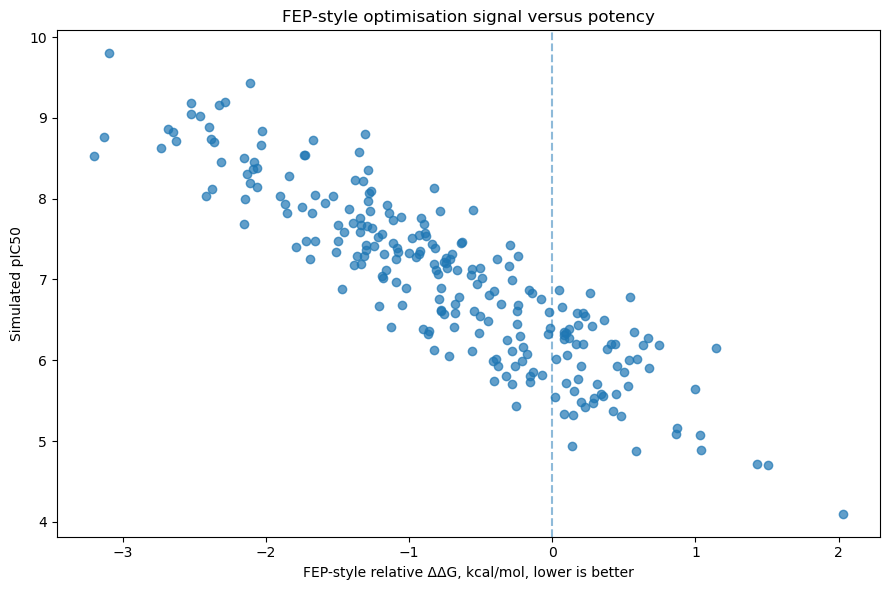

,compound_id,series,FEP_ddG_kcal_mol,docking_score_kcal_mol,pIC50,IC50_nM,lead_score
11,CMPD_0066,B_pyridine_core,-3.200,-10.018,8.523,2.997,23.648
4,CMPD_0149,A_urea_core,-3.131,-10.846,8.768,1.706,24.519
0,CMPD_0161,B_pyridine_core,-3.101,-11.251,9.800,0.158,26.059
17,CMPD_0095,C_indole_core,-2.734,-9.429,8.634,2.324,22.696
7,CMPD_0188,B_pyridine_core,-2.685,-10.262,8.868,1.356,24.124
9,CMPD_0118,A_urea_core,-2.648,-10.647,8.828,1.486,24.042
10,CMPD_0049,B_pyridine_core,-2.630,-10.200,8.713,1.936,23.870
2,CMPD_0235,A_urea_core,-2.527,-11.735,9.052,0.886,24.726
5,CMPD_0024,B_pyridine_core,-2.525,-10.847,9.180,0.660,24.363
1,CMPD_0174,A_urea_core,-2.462,-11.357,9.019,0.956,24.737


In [20]:
# 6. Quantum mechanics-style and FEP-style analysis

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["HOMO_LUMO_gap_eV"], df["pIC50"], alpha=0.75)
ax.set_xlabel("HOMO-LUMO gap, eV")
ax.set_ylabel("Simulated pIC50")
ax.set_title("Quantum-style electronic descriptor versus activity")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_qm_gap_vs_activity.png", dpi=220, bbox_inches="tight")
plt.show()

qm_table = df.sort_values("lead_score", ascending=False).head(12)[
    ["compound_id", "series", "HOMO_eV", "LUMO_eV", "HOMO_LUMO_gap_eV", "dipole_D", "pIC50", "docking_score_kcal_mol"]
]
display(qm_table.round(3))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["FEP_ddG_kcal_mol"], df["pIC50"], alpha=0.7)
ax.axvline(0, linestyle="--", alpha=0.5)
ax.set_xlabel("FEP-style relative ΔΔG, kcal/mol, lower is better")
ax.set_ylabel("Simulated pIC50")
ax.set_title("FEP-style optimisation signal versus potency")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_fep_vs_activity.png", dpi=220, bbox_inches="tight")
plt.show()

fep_hits = df.sort_values("FEP_ddG_kcal_mol").head(15)[
    ["compound_id", "series", "FEP_ddG_kcal_mol", "docking_score_kcal_mol", "pIC50", "IC50_nM", "lead_score"]
]
display(fep_hits.round(3))

## 7. QSAR modelling

QSAR classification ROC-AUC: 0.944
QSAR average precision: 0.973
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        21
           1       0.95      0.92      0.94        39

    accuracy                           0.92        60
   macro avg       0.91      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60



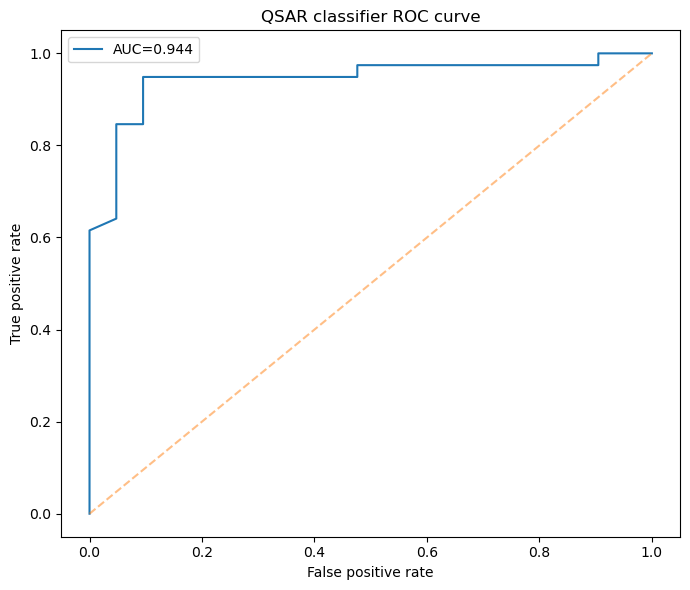

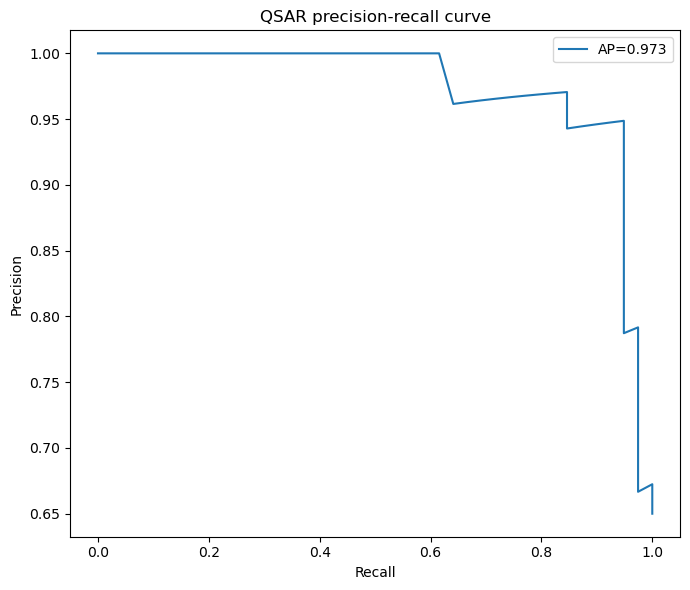

QSAR regression RMSE: 0.420
QSAR regression MAE:  0.326
QSAR regression R2:   0.866


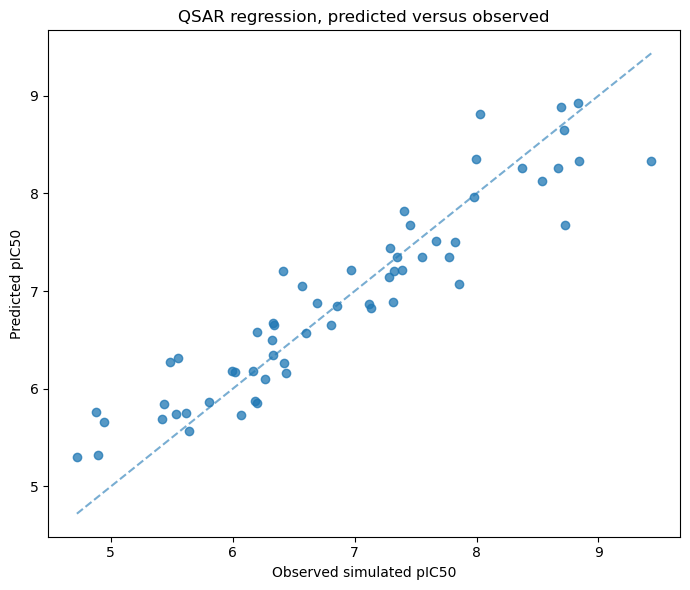

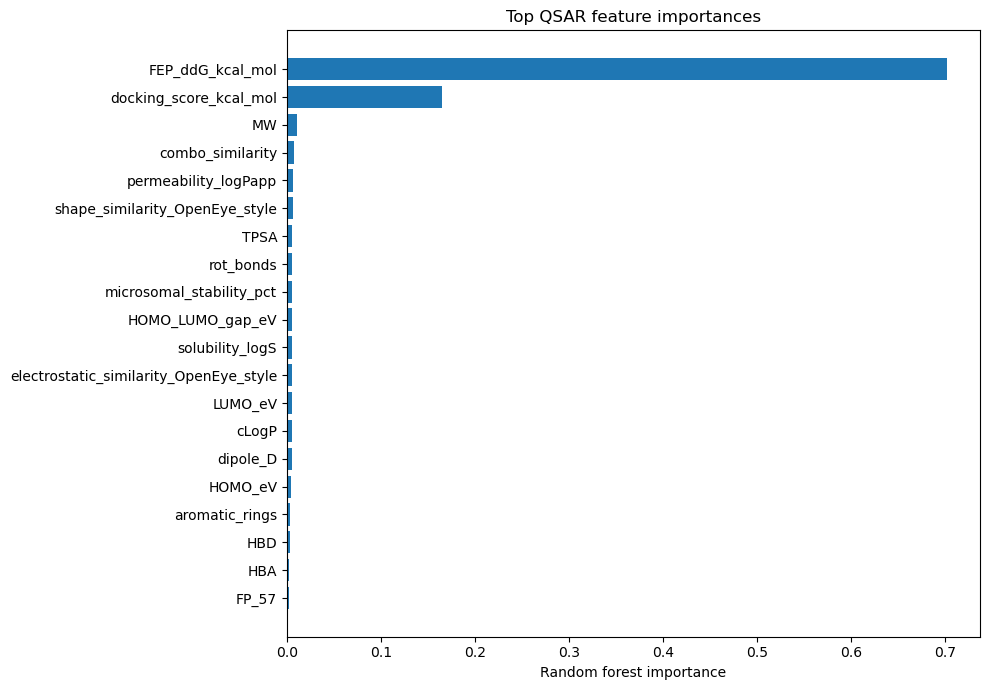

,model,endpoint,ROC_AUC,average_precision,RMSE,MAE,R2
0,RandomForestClassifier,active,0.944,0.973,NaN,NaN,NaN
1,RandomForestRegressor,pIC50,NaN,NaN,0.42,0.326,0.866


In [23]:
# 7. QSAR modelling

if not SKLEARN_AVAILABLE:
    print("scikit-learn is unavailable. Install with: pip install scikit-learn")
else:
    descriptor_cols = [
        "MW", "cLogP", "TPSA", "HBD", "HBA", "rot_bonds", "aromatic_rings", "formal_charge",
        "shape_similarity_OpenEye_style", "electrostatic_similarity_OpenEye_style",
        "combo_similarity", "docking_score_kcal_mol", "FEP_ddG_kcal_mol",
        "HOMO_eV", "LUMO_eV", "HOMO_LUMO_gap_eV", "dipole_D",
        "solubility_logS", "permeability_logPapp", "microsomal_stability_pct",
        "Lipinski_violations"
    ] + [f"FP_{i:02d}" for i in range(64)]

    X = df[descriptor_cols]
    y_cls = df["active"]
    y_reg = df["pIC50"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cls, test_size=0.25, random_state=42, stratify=y_cls
    )

    clf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced")
    clf.fit(X_train, y_train)
    prob = clf.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, prob)
    ap = average_precision_score(y_test, prob)
    print(f"QSAR classification ROC-AUC: {auc:.3f}")
    print(f"QSAR average precision: {ap:.3f}")
    print(classification_report(y_test, pred))

    fpr, tpr, _ = roc_curve(y_test, prob)
    precision, recall, _ = precision_recall_curve(y_test, prob)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", alpha=0.5)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("QSAR classifier ROC curve")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "09_qsar_roc.png", dpi=220, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(recall, precision, label=f"AP={ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("QSAR precision-recall curve")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_qsar_pr.png", dpi=220, bbox_inches="tight")
    plt.show()

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.25, random_state=42)
    reg = RandomForestRegressor(n_estimators=500, random_state=42)
    reg.fit(X_train_r, y_train_r)
    y_pred_r = reg.predict(X_test_r)

    try:
        from sklearn.metrics import root_mean_squared_error
        rmse = root_mean_squared_error(y_test_r, y_pred_r)
    except ImportError:
        rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae = mean_absolute_error(y_test_r, y_pred_r)
    r2 = r2_score(y_test_r, y_pred_r)

    print(f"QSAR regression RMSE: {rmse:.3f}")
    print(f"QSAR regression MAE:  {mae:.3f}")
    print(f"QSAR regression R2:   {r2:.3f}")

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_test_r, y_pred_r, alpha=0.75)
    low = min(y_test_r.min(), y_pred_r.min())
    high = max(y_test_r.max(), y_pred_r.max())
    ax.plot([low, high], [low, high], linestyle="--", alpha=0.6)
    ax.set_xlabel("Observed simulated pIC50")
    ax.set_ylabel("Predicted pIC50")
    ax.set_title("QSAR regression, predicted versus observed")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "11_qsar_predicted_observed.png", dpi=220, bbox_inches="tight")
    plt.show()

    importances = pd.Series(reg.feature_importances_, index=descriptor_cols).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(importances.index[::-1], importances.values[::-1])
    ax.set_xlabel("Random forest importance")
    ax.set_title("Top QSAR feature importances")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "12_qsar_feature_importance.png", dpi=220, bbox_inches="tight")
    plt.show()

    metrics = pd.DataFrame({
        "model": ["RandomForestClassifier", "RandomForestRegressor"],
        "endpoint": ["active", "pIC50"],
        "ROC_AUC": [auc, np.nan],
        "average_precision": [ap, np.nan],
        "RMSE": [np.nan, rmse],
        "MAE": [np.nan, mae],
        "R2": [np.nan, r2]
    })
    display(metrics.round(3))

## 8. Chemical-space PCA and Spotfire-style SAR dashboard

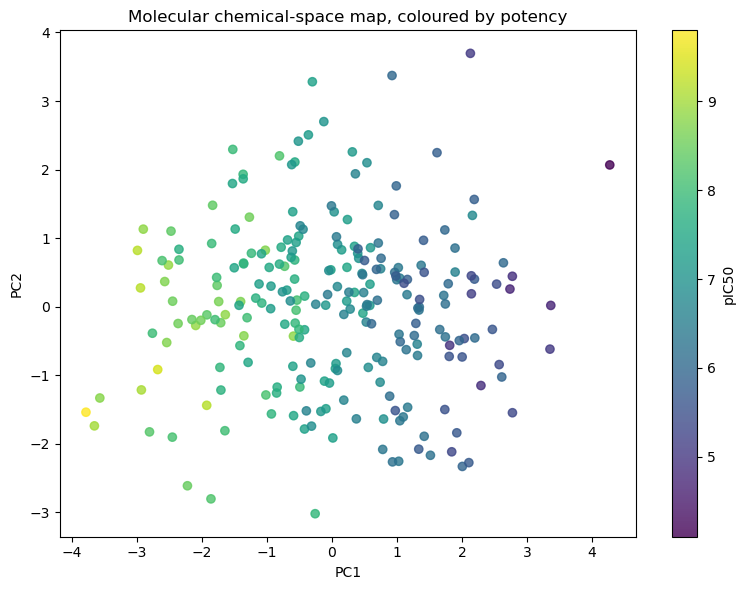

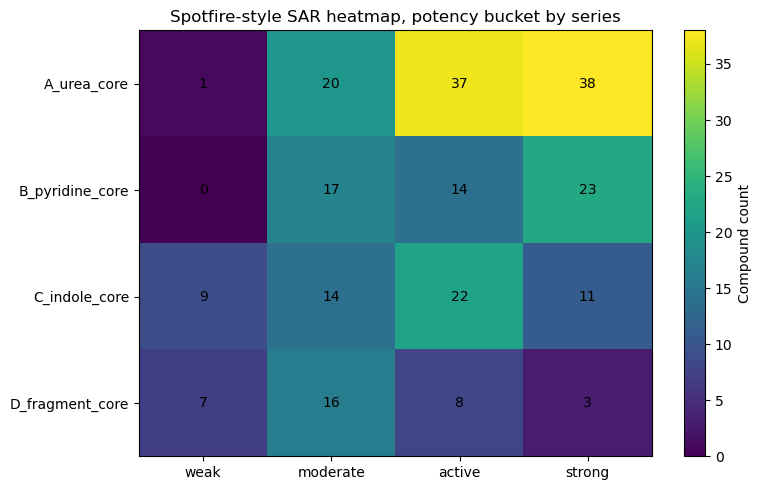

,compound_id,series,pIC50,IC50_nM,docking_score_kcal_mol,FEP_ddG_kcal_mol,shape_similarity_OpenEye_style,electrostatic_similarity_OpenEye_style,solubility_logS,microsomal_stability_pct,ADMET_flag,lead_score
0,CMPD_0161,B_pyridine_core,9.800,0.158,-11.251,-3.101,0.846,0.823,-3.255,29.320,acceptable,26.059
1,CMPD_0174,A_urea_core,9.019,0.956,-11.357,-2.462,0.945,0.895,-1.855,38.579,acceptable,24.737
2,CMPD_0235,A_urea_core,9.052,0.886,-11.735,-2.527,0.777,0.717,-4.056,45.677,acceptable,24.726
4,CMPD_0149,A_urea_core,8.768,1.706,-10.846,-3.131,0.758,0.702,-2.126,42.560,acceptable,24.519
5,CMPD_0024,B_pyridine_core,9.180,0.660,-10.847,-2.525,0.868,0.737,-3.660,29.293,acceptable,24.363
6,CMPD_0202,A_urea_core,9.433,0.369,-10.562,-2.112,0.961,0.878,-3.273,45.830,acceptable,24.241
7,CMPD_0188,B_pyridine_core,8.868,1.356,-10.262,-2.685,0.954,0.640,-3.297,52.324,acceptable,24.124
8,CMPD_0005,A_urea_core,9.162,0.688,-10.485,-2.333,0.916,0.806,-3.859,36.684,acceptable,24.117
9,CMPD_0118,A_urea_core,8.828,1.486,-10.647,-2.648,0.990,0.811,-3.733,34.331,acceptable,24.042
10,CMPD_0049,B_pyridine_core,8.713,1.936,-10.200,-2.630,0.951,0.654,-1.264,54.840,acceptable,23.870


In [26]:
# 8. Chemical-space PCA and Spotfire-style SAR dashboard

if SKLEARN_AVAILABLE:
    pca_features = ["MW", "cLogP", "TPSA", "HBD", "HBA", "rot_bonds", "aromatic_rings",
                    "shape_similarity_OpenEye_style", "electrostatic_similarity_OpenEye_style",
                    "docking_score_kcal_mol", "FEP_ddG_kcal_mol", "HOMO_LUMO_gap_eV", "dipole_D"]
    scaled = StandardScaler().fit_transform(df[pca_features])
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(scaled)
    df["PC1"] = coords[:, 0]
    df["PC2"] = coords[:, 1]

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(df["PC1"], df["PC2"], c=df["pIC50"], alpha=0.8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("Molecular chemical-space map, coloured by potency")
    cb = plt.colorbar(scatter, ax=ax)
    cb.set_label("pIC50")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "13_pca_chemical_space.png", dpi=220, bbox_inches="tight")
    plt.show()

sar = df.copy()
sar["potency_bucket"] = pd.cut(sar["pIC50"], bins=[0, 5.5, 6.5, 7.5, 10], labels=["weak", "moderate", "active", "strong"])
pivot = sar.pivot_table(index="series", columns="potency_bucket", values="compound_id", aggfunc="count", fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_title("Spotfire-style SAR heatmap, potency bucket by series")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, pivot.values[i, j], ha="center", va="center")
plt.colorbar(im, ax=ax, label="Compound count")
plt.tight_layout()
plt.savefig(FIG_DIR / "14_spotfire_style_sar_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

decision_table = df[
    (df["pIC50"] >= 6.8)
    & (df["docking_score_kcal_mol"] <= -8.0)
    & (df["FEP_ddG_kcal_mol"] <= 0.25)
    & (df["combo_similarity"] >= 0.70)
].sort_values("lead_score", ascending=False).head(20)

decision_table = decision_table[
    ["compound_id", "series", "pIC50", "IC50_nM", "docking_score_kcal_mol", "FEP_ddG_kcal_mol",
     "shape_similarity_OpenEye_style", "electrostatic_similarity_OpenEye_style",
     "solubility_logS", "microsomal_stability_pct", "ADMET_flag", "lead_score"]
]
display(decision_table.round(3))

## 9. OpenEye-style molecular similarity and integrated decision engine

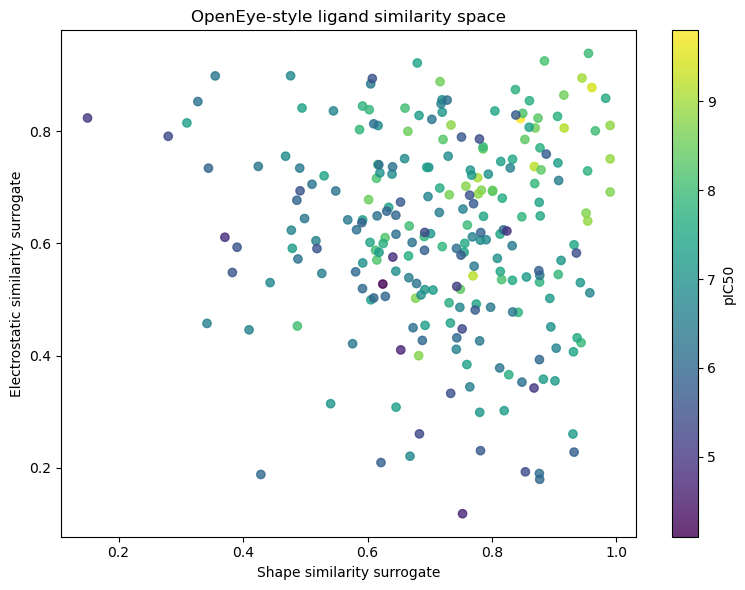

,compound_id,series,shape_similarity_OpenEye_style,electrostatic_similarity_OpenEye_style,combo_similarity,docking_score_kcal_mol,pIC50,ADMET_flag,lead_score
45,CMPD_0135,D_fragment_core,0.955,0.939,0.948,-10.089,7.976,acceptable,21.097
66,CMPD_0078,A_urea_core,0.983,0.859,0.927,-9.222,7.556,acceptable,20.071
6,CMPD_0202,A_urea_core,0.961,0.878,0.924,-10.562,9.433,acceptable,24.241
1,CMPD_0174,A_urea_core,0.945,0.895,0.922,-11.357,9.019,acceptable,24.737
9,CMPD_0118,A_urea_core,0.990,0.811,0.909,-10.647,8.828,acceptable,24.042
13,CMPD_0165,A_urea_core,0.884,0.926,0.903,-10.390,8.117,acceptable,23.236
30,CMPD_0103,A_urea_core,0.916,0.865,0.893,-10.332,8.541,risk,22.031
44,CMPD_0209,A_urea_core,0.966,0.801,0.892,-8.858,8.030,acceptable,21.169
12,CMPD_0011,A_urea_core,0.990,0.751,0.882,-9.872,8.883,acceptable,23.289
62,CMPD_0087,C_indole_core,0.905,0.827,0.870,-9.122,7.700,acceptable,20.200


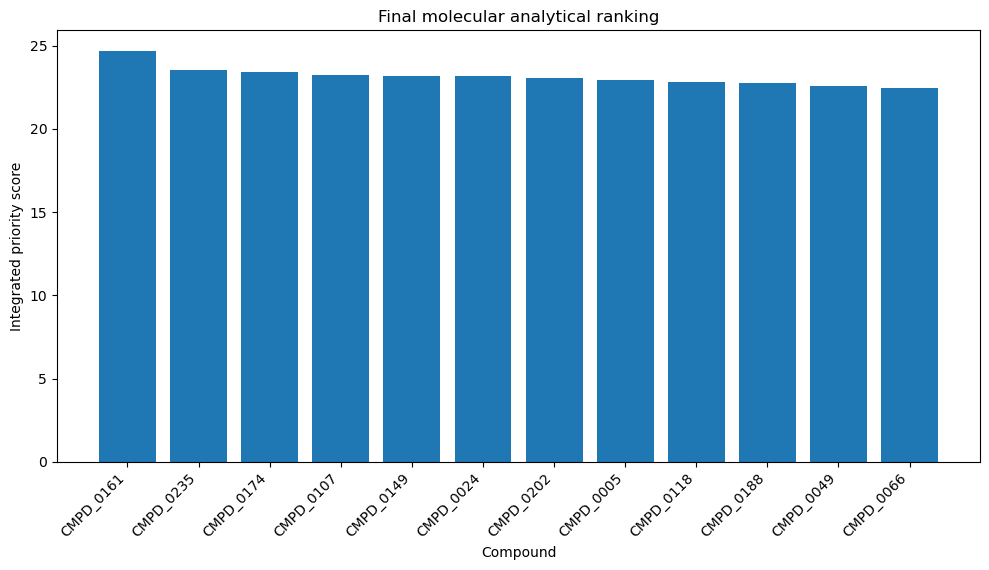

,compound_id,series,pIC50,IC50_nM,docking_score_kcal_mol,FEP_ddG_kcal_mol,MD_mean_RMSD_proxy_nm,MD_ligand_retention_proxy,combo_similarity,ADMET_flag,integrated_priority_score
0,CMPD_0161,B_pyridine_core,9.800,0.158,-11.251,-3.101,0.242,1.000,0.835,acceptable,24.692
2,CMPD_0235,A_urea_core,9.052,0.886,-11.735,-2.527,0.211,0.953,0.750,acceptable,23.522
1,CMPD_0174,A_urea_core,9.019,0.956,-11.357,-2.462,0.243,0.915,0.922,acceptable,23.433
3,CMPD_0107,B_pyridine_core,9.193,0.641,-11.399,-2.288,0.241,0.905,0.667,acceptable,23.223
4,CMPD_0149,A_urea_core,8.768,1.706,-10.846,-3.131,0.264,0.915,0.733,acceptable,23.179
5,CMPD_0024,B_pyridine_core,9.180,0.660,-10.847,-2.525,0.194,1.000,0.809,acceptable,23.178
6,CMPD_0202,A_urea_core,9.433,0.369,-10.562,-2.112,0.206,1.000,0.924,acceptable,23.064
8,CMPD_0005,A_urea_core,9.162,0.688,-10.485,-2.333,0.220,1.000,0.867,acceptable,22.918
9,CMPD_0118,A_urea_core,8.828,1.486,-10.647,-2.648,0.269,0.969,0.909,acceptable,22.850
7,CMPD_0188,B_pyridine_core,8.868,1.356,-10.262,-2.685,0.199,0.938,0.813,acceptable,22.789


In [29]:
# 9. OpenEye-style molecular similarity and final integrated decision engine

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    df["shape_similarity_OpenEye_style"],
    df["electrostatic_similarity_OpenEye_style"],
    c=df["pIC50"],
    alpha=0.8
)
ax.set_xlabel("Shape similarity surrogate")
ax.set_ylabel("Electrostatic similarity surrogate")
ax.set_title("OpenEye-style ligand similarity space")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("pIC50")
plt.tight_layout()
plt.savefig(FIG_DIR / "15_openeye_style_similarity_space.png", dpi=220, bbox_inches="tight")
plt.show()

openeye_top = df.sort_values("combo_similarity", ascending=False).head(15)[
    ["compound_id", "series", "shape_similarity_OpenEye_style", "electrostatic_similarity_OpenEye_style",
     "combo_similarity", "docking_score_kcal_mol", "pIC50", "ADMET_flag", "lead_score"]
]
display(openeye_top.round(3))

# Integrated decision engine
top30 = df.head(30).copy()
top30["MD_mean_RMSD_proxy_nm"] = np.clip(
    0.45 - 0.025 * top30["pIC50"] + 0.03 * np.maximum(top30["FEP_ddG_kcal_mol"], 0) + np.random.normal(0, 0.03, len(top30)),
    0.12, 0.55
)
top30["MD_ligand_retention_proxy"] = np.clip(
    1.2 - top30["MD_mean_RMSD_proxy_nm"] - 0.08 * np.maximum(top30["FEP_ddG_kcal_mol"], 0) + np.random.normal(0, 0.05, len(top30)),
    0, 1
)

top30["integrated_priority_score"] = (
    1.2 * top30["pIC50"]
    + 0.7 * (-top30["docking_score_kcal_mol"])
    + 0.8 * (-top30["FEP_ddG_kcal_mol"])
    + 1.3 * top30["MD_ligand_retention_proxy"]
    + 1.0 * top30["combo_similarity"]
    + 0.015 * top30["microsomal_stability_pct"]
    - 0.25 * top30["Lipinski_violations"]
)

final = top30.sort_values("integrated_priority_score", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.bar(final["compound_id"], final["integrated_priority_score"])
ax.set_xlabel("Compound")
ax.set_ylabel("Integrated priority score")
ax.set_title("Final molecular analytical ranking")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "16_integrated_priority_ranking.png", dpi=220, bbox_inches="tight")
plt.show()

final_table = final[
    ["compound_id", "series", "pIC50", "IC50_nM", "docking_score_kcal_mol", "FEP_ddG_kcal_mol",
     "MD_mean_RMSD_proxy_nm", "MD_ligand_retention_proxy", "combo_similarity",
     "ADMET_flag", "integrated_priority_score"]
].round(3)

final_table.to_csv("final_prioritised_compounds.csv", index=False)
display(final_table)

## 10. Example real-world command templates

### GROMACS-style real workflow

These commands are examples for a real GROMACS run. They are not executed in this notebook.

```bash
gmx pdb2gmx -f protein.pdb -o processed.gro -water tip3p
gmx editconf -f processed.gro -o boxed.gro -c -d 1.0 -bt cubic
gmx solvate -cp boxed.gro -cs spc216.gro -o solvated.gro -p topol.top
gmx grompp -f ions.mdp -c solvated.gro -p topol.top -o ions.tpr
gmx genion -s ions.tpr -o solvated_ions.gro -p topol.top -pname NA -nname CL -neutral
gmx grompp -f minim.mdp -c solvated_ions.gro -p topol.top -o em.tpr
gmx mdrun -deffnm em
gmx grompp -f nvt.mdp -c em.gro -p topol.top -o nvt.tpr
gmx mdrun -deffnm nvt
gmx grompp -f npt.mdp -c nvt.gro -p topol.top -o npt.tpr
gmx mdrun -deffnm npt
gmx grompp -f md.mdp -c npt.gro -p topol.top -o md.tpr
gmx mdrun -deffnm md
gmx rms -s md.tpr -f md.xtc -o rmsd.xvg
gmx rmsf -s md.tpr -f md.xtc -o rmsf.xvg
gmx gyrate -s md.tpr -f md.xtc -o gyrate.xvg
gmx hbond -s md.tpr -f md.xtc -num hbonds.xvg
```

### AutoDock Vina-style real workflow

```bash
vina --receptor receptor.pdbqt --ligand ligand.pdbqt \
     --center_x 10 --center_y 15 --center_z 20 \
     --size_x 20 --size_y 20 --size_z 20 \
     --out ligand_docked.pdbqt --log ligand_log.txt
```

### Interview explanation

> "This notebook shows that I understand the molecular analytical logic behind GROMACS, MD, docking, virtual screening, QM, FEP, QSAR, Spotfire-style SAR analytics, and OpenEye-style molecular similarity. My strongest hands-on area is Python-based cheminformatics, QSAR, ML, and compound prioritisation, but I understand how these tools integrate strategically in drug discovery."